#### Import Libraries AND Load Dataset:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\user\Downloads\creditcard.csv")
print("Shape:", df.shape)
print("Fraud Cases:", df['Class'].sum())
print("Fraud %:", round(df['Class'].mean()*100, 3), "%")

Shape: (284807, 31)
Fraud Cases: 492
Fraud %: 0.173 %


 #### Fraud vs Legit Amount:

In [2]:
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

print("Avg Fraud Amount: $", round(fraud['Amount'].mean(), 2))
print("Avg Legit Amount: $", round(legit['Amount'].mean(), 2))
print("Max Fraud Amount: $", fraud['Amount'].max())
print("Total Fraud Value: $", round(fraud['Amount'].sum(), 2))

Avg Fraud Amount: $ 122.21
Avg Legit Amount: $ 88.29
Max Fraud Amount: $ 2125.87
Total Fraud Value: $ 60127.97


#### Hour Based Pattern:

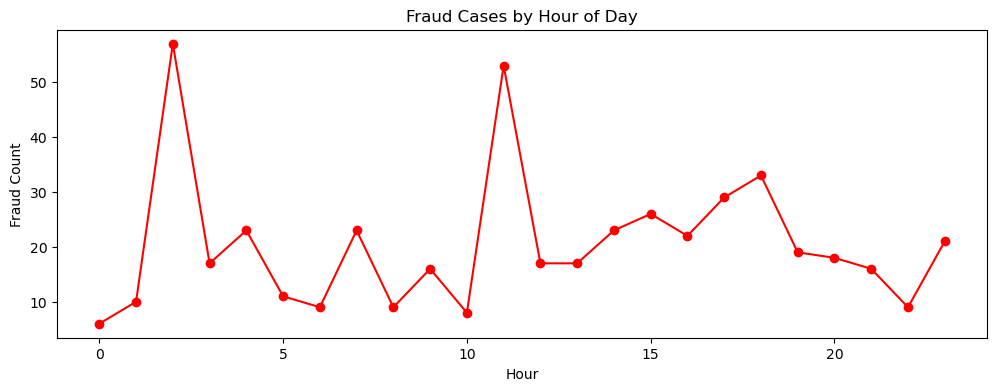

Peak fraud hour: 2


In [3]:
df['Hour'] = (df['Time'] / 3600).astype(int) % 24

fraud_by_hour = df[df['Class']==1].groupby('Hour').size()

plt.figure(figsize=(12,4))
plt.plot(fraud_by_hour.index, fraud_by_hour.values, color='red', marker='o')
plt.title('Fraud Cases by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Fraud Count')
plt.savefig(r"C:\Users\user\Downloads\fraud_by_hour.png")
plt.show()
print("Peak fraud hour:", fraud_by_hour.idxmax())

##### Amount Range Analysis:

In [4]:
bins = [0, 50, 100, 200, 500, 1000, 5000, 30000]
labels = ['0-50','50-100','100-200','200-500','500-1K','1K-5K','5K+']

df['Amount_Range'] = pd.cut(df['Amount'], bins=bins, labels=labels)

fraud_by_amount = df[df['Class']==1].groupby('Amount_Range', observed=True).size()
print("Fraud by Amount Range:")
print(fraud_by_amount)

Fraud by Amount Range:
Amount_Range
0-50       279
50-100      56
100-200     45
200-500     50
500-1K      26
1K-5K        9
dtype: int64


#### CSV File saved

In [14]:
import pandas as pd

df = pd.read_csv(r"C:\Users\user\Downloads\creditcard_analyzed.csv")
df = df.fillna(0)
df['Amount_Range'] = df['Amount_Range'].astype(str).replace('nan', 'Unknown')

print("Nulls:", df.isnull().sum().sum())
print("Shape:", df.shape)

df.to_csv(r"C:\Users\user\Downloads\creditcard_clean.csv", index=False)
print("Saved")

Nulls: 0
Shape: (284807, 33)
Saved


In [12]:
import subprocess
subprocess.run(['pip', 'install', 'psycopg2-binary', 'sqlalchemy'], capture_output=True)
print("Done")

Done
